#Visualisation des données

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical

url_train = "https://maxime-devanne.com/datasets/Earthquakes/Earthquakes_TRAIN.tsv"
url_test = "https://maxime-devanne.com/datasets/Earthquakes/Earthquakes_TEST.tsv"

train_path = pd.read_csv(url_train, sep='\t', header=None)
test_path = pd.read_csv(url_test, sep='\t', header=None)


train_path.head()

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,512
0,1,-0.518009,-0.518009,2.654211,-0.518009,-0.518009,-0.518009,-0.518009,1.456243,2.558373,...,-0.518009,-0.518009,-0.518009,-0.518009,-0.518009,-0.518009,-0.518009,-0.518009,1.465826,-0.518009
1,0,1.943733,-0.353115,-0.353115,-0.353115,-0.353115,-0.353115,-0.353115,-0.353115,-0.353115,...,2.457789,3.365590,-0.353115,-0.353115,-0.353115,-0.353115,-0.353115,-0.353115,-0.353115,-0.353115
2,0,2.638517,-0.316102,-0.316102,-0.316102,-0.316102,-0.316102,-0.316102,-0.316102,-0.316102,...,-0.316102,-0.316102,-0.316102,-0.316102,-0.316102,-0.316102,-0.316102,-0.316102,-0.316102,-0.316102
3,0,-0.531138,-0.531138,-0.531138,-0.531138,-0.531138,-0.531138,-0.531138,-0.531138,-0.531138,...,1.366900,-0.531138,2.147402,-0.531138,-0.531138,-0.531138,-0.531138,-0.531138,-0.531138,-0.531138
4,1,-0.593665,2.020105,1.174727,-0.593665,-0.593665,1.606043,1.217859,1.588790,-0.593665,...,1.226485,-0.593665,-0.593665,-0.593665,1.493901,-0.593665,-0.593665,-0.593665,1.899337,-0.593665


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(url_train, sep='\t', header=None)

df = df.rename(columns={0: 'Classe'})
print(df.shape)

dataset=df.copy()
dataset = dataset.dropna()
print(dataset.shape)
print(df.head())

print(df['Classe'])

class_0 = df[df['Classe'] == 0].iloc[:, 1:].values
class_1 = df[df['Classe'] == 1].iloc[:, 1:].values



(322, 513)
(322, 513)
   Classe         1         2         3         4         5         6  \
0       1 -0.518009 -0.518009  2.654211 -0.518009 -0.518009 -0.518009   
1       0  1.943733 -0.353115 -0.353115 -0.353115 -0.353115 -0.353115   
2       0  2.638517 -0.316102 -0.316102 -0.316102 -0.316102 -0.316102   
3       0 -0.531138 -0.531138 -0.531138 -0.531138 -0.531138 -0.531138   
4       1 -0.593665  2.020105  1.174727 -0.593665 -0.593665  1.606043   

          7         8         9  ...       503       504       505       506  \
0 -0.518009  1.456243  2.558373  ... -0.518009 -0.518009 -0.518009 -0.518009   
1 -0.353115 -0.353115 -0.353115  ...  2.457789  3.365590 -0.353115 -0.353115   
2 -0.316102 -0.316102 -0.316102  ... -0.316102 -0.316102 -0.316102 -0.316102   
3 -0.531138 -0.531138 -0.531138  ...  1.366900 -0.531138  2.147402 -0.531138   
4  1.217859  1.588790 -0.593665  ...  1.226485 -0.593665 -0.593665 -0.593665   

        507       508       509       510       511       

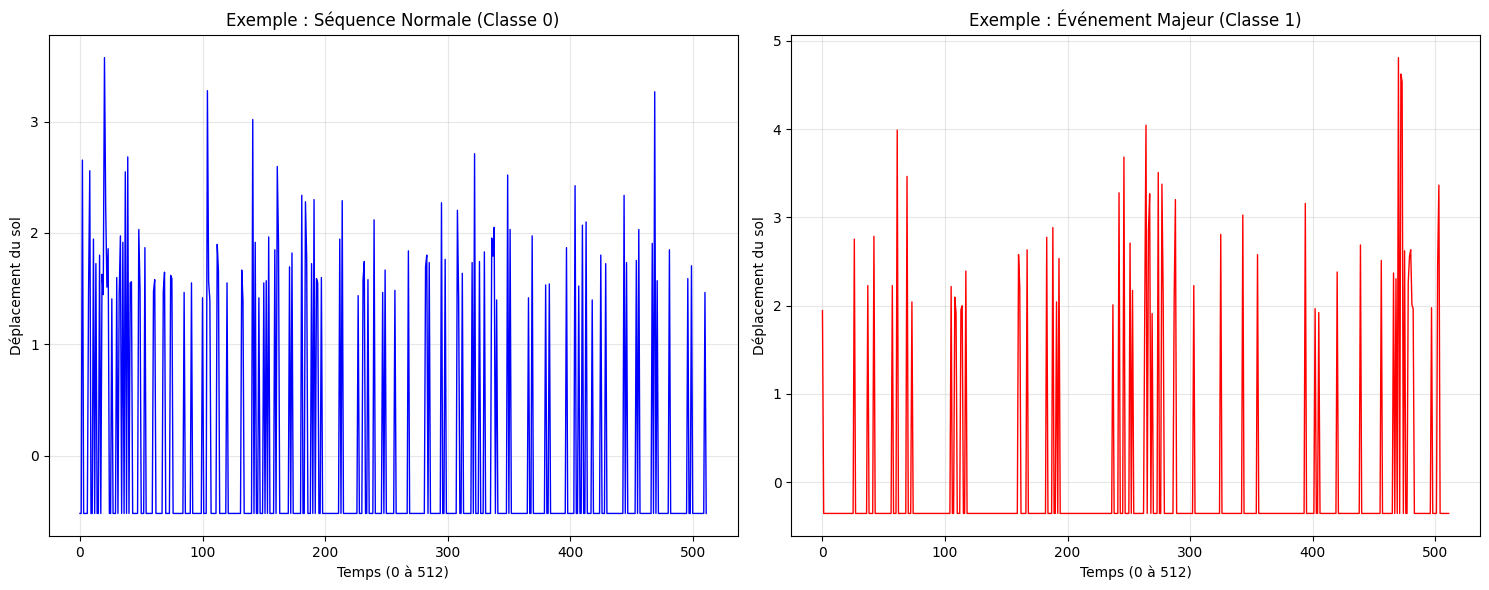

In [3]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 2)
plt.plot(class_0[0], color='red', linewidth=1)
plt.title("Exemple : Événement Majeur (Classe 1)")
plt.xlabel("Temps (0 à 512)")
plt.ylabel("Déplacement du sol")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 1)
plt.plot(class_1[0], color='blue', linewidth=1)
plt.title("Exemple : Séquence Normale (Classe 0)")
plt.xlabel("Temps (0 à 512)")
plt.ylabel("Déplacement du sol")
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

#MLP


Chargement des données...
Données chargées. Train: (322, 512), Test: (139, 512)
Classes détectées : [0 1] (mappées vers [0 1])


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 500)            │       256,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 758,001 (2.89 MB)

 Trainable params: 758,001 (2.89 MB)

 Non-trainable params: 0 (0.00 B)


Lancement de l'entraînement (Max 500 epochs)...
Poids des classes : {0: np.float64(0.6098484848484849), 1: np.float64(2.7758620689655173)}
Epoch 1/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5880 - loss: 0.6970 - val_accuracy: 0.5180 - val_loss: 0.6999 - learning_rate: 0.0010
Epoch 2/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5791 - loss: 0.7025 - val_accuracy: 0.5180 - val_loss: 0.6987 - learning_rate: 0.0010
Epoch 3/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5371 - loss: 0.7629 - val_accuracy: 0.5180 - val_loss: 0.6979 - learning_rate: 0.0010
Epoch 4/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5888 - loss: 0.7178 - val_accuracy: 0.5180 - val_loss: 0.6971 - learning_rate: 0.0010
Epoch 5/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5524 - loss: 0.7271 - val_accuracy: 0.5252 - val_loss: 0.6960 - learning_rate: 0.0010
Epoch 6/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5241 - loss: 0.6881 - val_accuracy

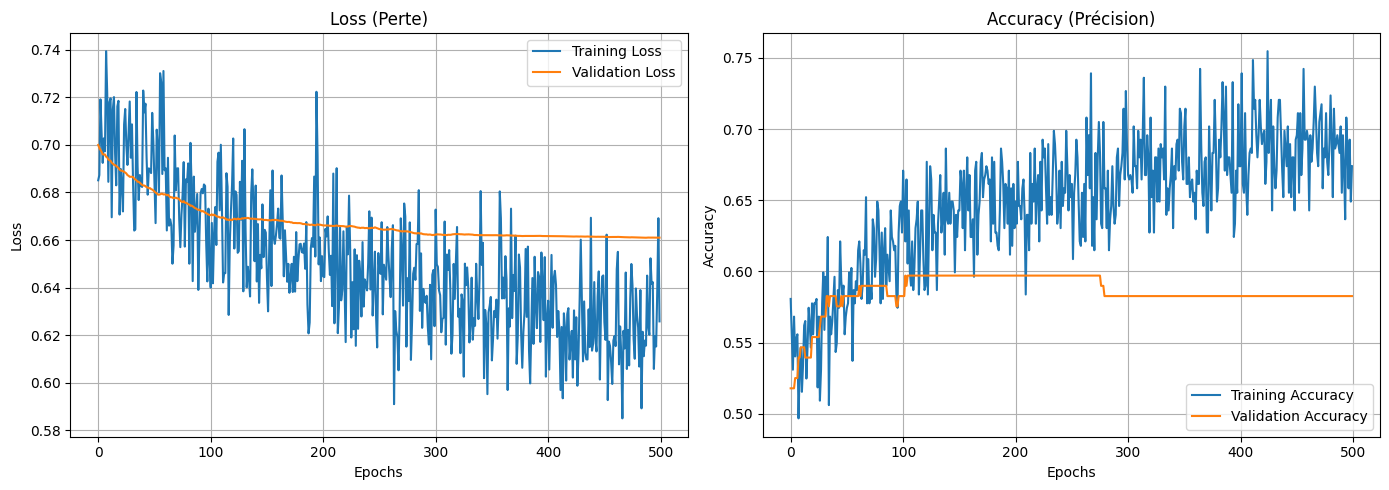

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

--- RÉSULTATS ---
Accuracy Test : 58.27%

Rapport de classification :
              precision    recall  f1-score   support

           0       0.72      0.73      0.72       104
           1       0.15      0.14      0.15        35

    accuracy                           0.58       139
   macro avg       0.43      0.44      0.44       139
weighted avg       0.57      0.58      0.58       139



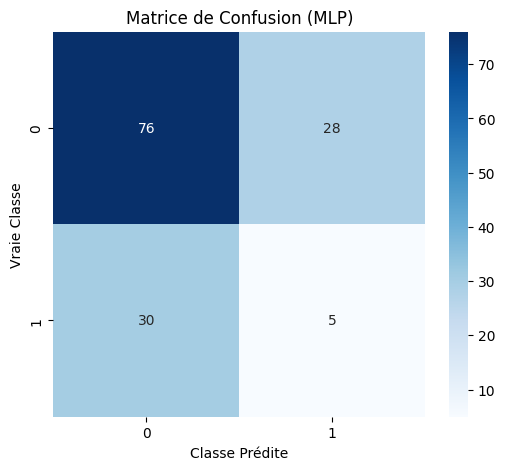

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight

TRAIN_URL = "https://maxime-devanne.com/datasets/Earthquakes/Earthquakes_TRAIN.tsv"
TEST_URL  = "https://maxime-devanne.com/datasets/Earthquakes/Earthquakes_TEST.tsv"

print("Chargement des données...")
df_train = pd.read_csv(TRAIN_URL, sep='\t', header=None)
df_test  = pd.read_csv(TEST_URL, sep='\t', header=None)

y_train_raw = df_train.iloc[:, 0].values
X_train = df_train.iloc[:, 1:].values
y_test_raw  = df_test.iloc[:, 0].values
X_test  = df_test.iloc[:, 1:].values

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test  = le.transform(y_test_raw)

nb_classes = len(np.unique(y_train))
input_shape = (X_train.shape[1],)

print(f"Données chargées. Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes détectées : {le.classes_} (mappées vers {np.unique(y_train)})")

def build_mlp_benchmark(input_shape, nb_classes):
    inputs = keras.Input(shape=input_shape)

    # Bloc 1
    x = layers.Dropout(0.1)(inputs)
    x = layers.Dense(500, activation='relu')(x)

    # Bloc 2
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(500, activation='relu')(x)

    # Bloc 3
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(500, activation='relu')(x)

    # Sortie
    x = layers.Dropout(0.3)(x)

    if nb_classes == 2:
        outputs = layers.Dense(1, activation='sigmoid')(x)
        loss = 'binary_crossentropy'
    else:
        outputs = layers.Dense(nb_classes, activation='softmax')(x)
        loss = 'sparse_categorical_crossentropy'

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model, loss

model, loss_type = build_mlp_benchmark(input_shape, nb_classes)

model.compile(optimizer='adadelta',
              loss=loss_type,
              metrics=['accuracy'])
model.summary()
callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20, min_lr=0.0001),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
]

print("\nLancement de l'entraînement (Max 500 epochs)...")

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {i: w for i, w in enumerate(weights)}

print(f"Poids des classes : {class_weights_dict}")

# Lancez l'entraînement
history = model.fit(
    X_train, y_train,
    batch_size=16,
    epochs=500,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=1
)

def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Graphique de la Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss (Perte)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    # Graphique de l'Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy (Précision)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Appel de la fonction de visualisation
plot_learning_curves(history)

y_pred_proba = model.predict(X_test)
if nb_classes == 2:
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
else:
    y_pred = np.argmax(y_pred_proba, axis=1)

final_acc = np.mean(y_pred == y_test)
print(f"\n--- RÉSULTATS ---")
print(f"Accuracy Test : {final_acc*100:.2f}%")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrice de Confusion (MLP)')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.show()

#CNN

Shapes: (257, 512, 1) (65, 512, 1) (139, 512, 1)
Class weights: {0: np.float64(0.6090047393364929), 1: np.float64(2.7934782608695654)}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 512, 32)        │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 256, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 256, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 128, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 128, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,513 (173.88 KB)

 Trainable params: 44,065 (172.13 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6065 - auc_pr: 0.1872 - auc_roc: 0.4884 - loss: 0.7323 - precision: 0.1200 - recall: 0.2073
Epoch 1: val_auc_pr improved from -inf to 0.23109, saving model to best_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step - accuracy: 0.6043 - auc_pr: 0.1887 - auc_roc: 0.4872 - loss: 0.7372 - precision: 0.1253 - recall: 0.2180 - val_accuracy: 0.1846 - val_auc_pr: 0.2311 - val_auc_roc: 0.6242 - val_loss: 1.0592 - val_precision: 0.1846 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/100
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4403 - auc_pr: 0.2847 - auc_roc: 0.5885 - loss: 0.7693 - precision: 0.2601 - recall: 0.7796
Epoch 2: val_auc_pr improved from 0.23109 to 0.32772, saving model to best_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.4184 - auc_pr: 0.2729 - auc_roc: 0.5804 - loss: 0.7645 - precision: 0.2445 - recall: 0.7802 - val_accuracy: 0.1846 - val_auc_pr: 0.3277 - val_auc_roc: 0.6753 - val_lo

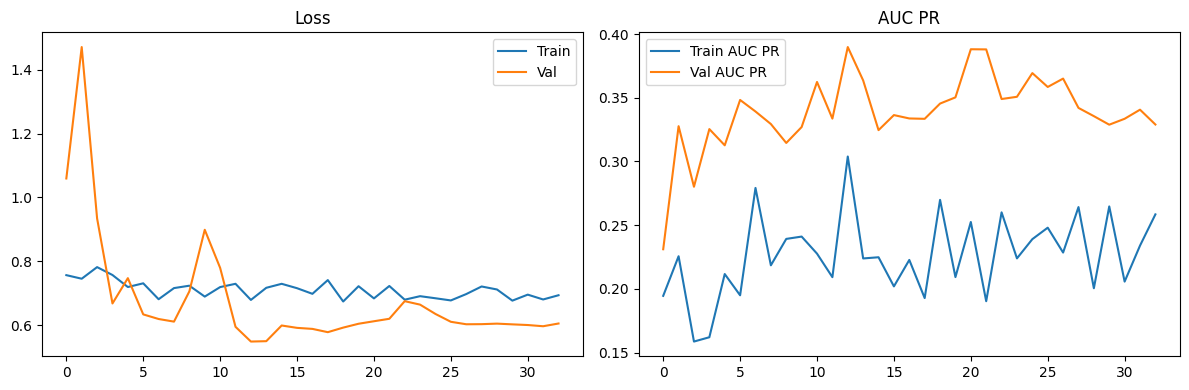

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       104
           1       0.00      0.00      0.00        35

    accuracy                           0.75       139
   macro avg       0.37      0.50      0.43       139
weighted avg       0.56      0.75      0.64       139



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


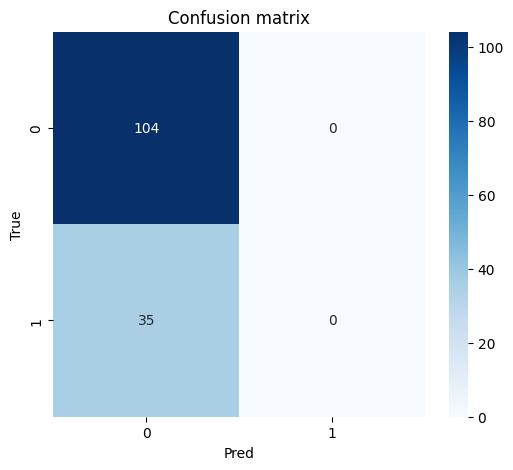

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-3
SEED = 42

train_url = "https://maxime-devanne.com/datasets/Earthquakes/Earthquakes_TRAIN.tsv"
test_url  = "https://maxime-devanne.com/datasets/Earthquakes/Earthquakes_TEST.tsv"

train_df = pd.read_csv(train_url, sep="\t", header=None)
test_df  = pd.read_csv(test_url,  sep="\t", header=None)

y_train_raw = train_df.iloc[:, 0].values
X_train_raw = train_df.iloc[:, 1:].values.astype(np.float32)

y_test_raw = test_df.iloc[:, 0].values
X_test_raw = test_df.iloc[:, 1:].values.astype(np.float32)


le = LabelEncoder()
y_train_all = le.fit_transform(y_train_raw).astype(np.int32)
y_test = le.transform(y_test_raw).astype(np.int32)


X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_raw, y_train_all,
    test_size=0.2,
    stratify=y_train_all
)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test_raw)

X_tr  = X_tr[..., None]
X_val = X_val[..., None]
X_test = X_test[..., None]

print("Shapes:", X_tr.shape, X_val.shape, X_test.shape)

cw = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_tr),
    y=y_tr
)
class_weights_dict = dict(enumerate(cw))
print("Class weights:", class_weights_dict)

train_ds = tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
train_ds = train_ds.shuffle(min(len(X_tr), 10_000), seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

def build_cnn_model(input_shape):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv1D(32, 8, padding="same", kernel_initializer="he_normal")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.SpatialDropout1D(0.2)(x)

    x = layers.Conv1D(64, 5, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.SpatialDropout1D(0.3)(x)

    x = layers.Conv1D(
        128, 3, padding="same",
        kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inp, out)

model = build_cnn_model((X_tr.shape[1], 1))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc_roc"),
        tf.keras.metrics.AUC(name="auc_pr", curve="PR"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

model.summary()

cb = [
    callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_auc_pr",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_auc_pr",
        mode="max",
        patience=20,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_auc_pr",
        mode="max",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=cb,
    verbose=1,
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["auc_pr"], label="Train AUC PR")
plt.plot(history.history["val_auc_pr"], label="Val AUC PR")
plt.title("AUC PR")
plt.legend()

plt.tight_layout()
plt.show()

y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion matrix")
plt.ylabel("True")
plt.xlabel("Pred")
plt.show()


#RNN

Chargement...

EXPLORATION DES DONNÉES

Nombre d'échantillons d'entraînement : 322
Nombre d'échantillons de test : 139
Longueur de chaque série temporelle : 512 points
Classes présentes : [0 1]


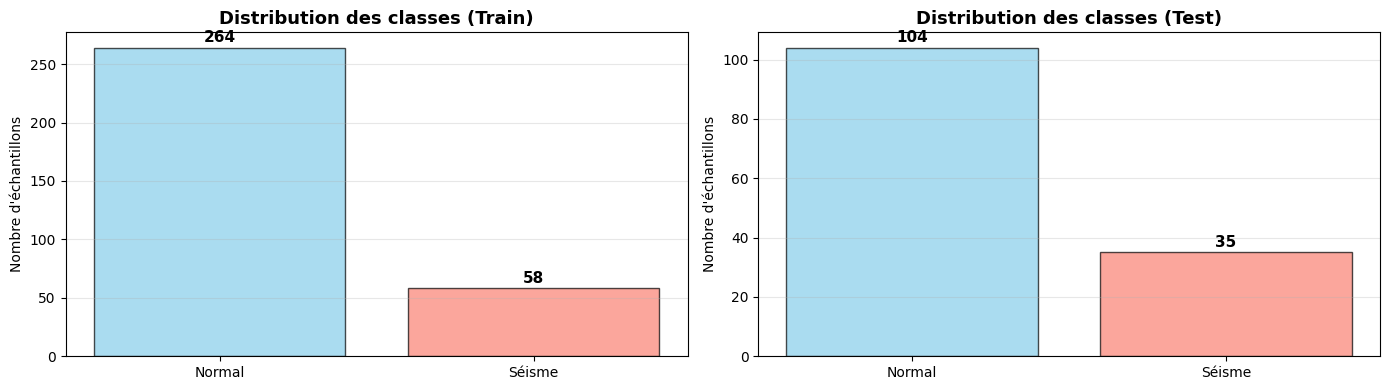

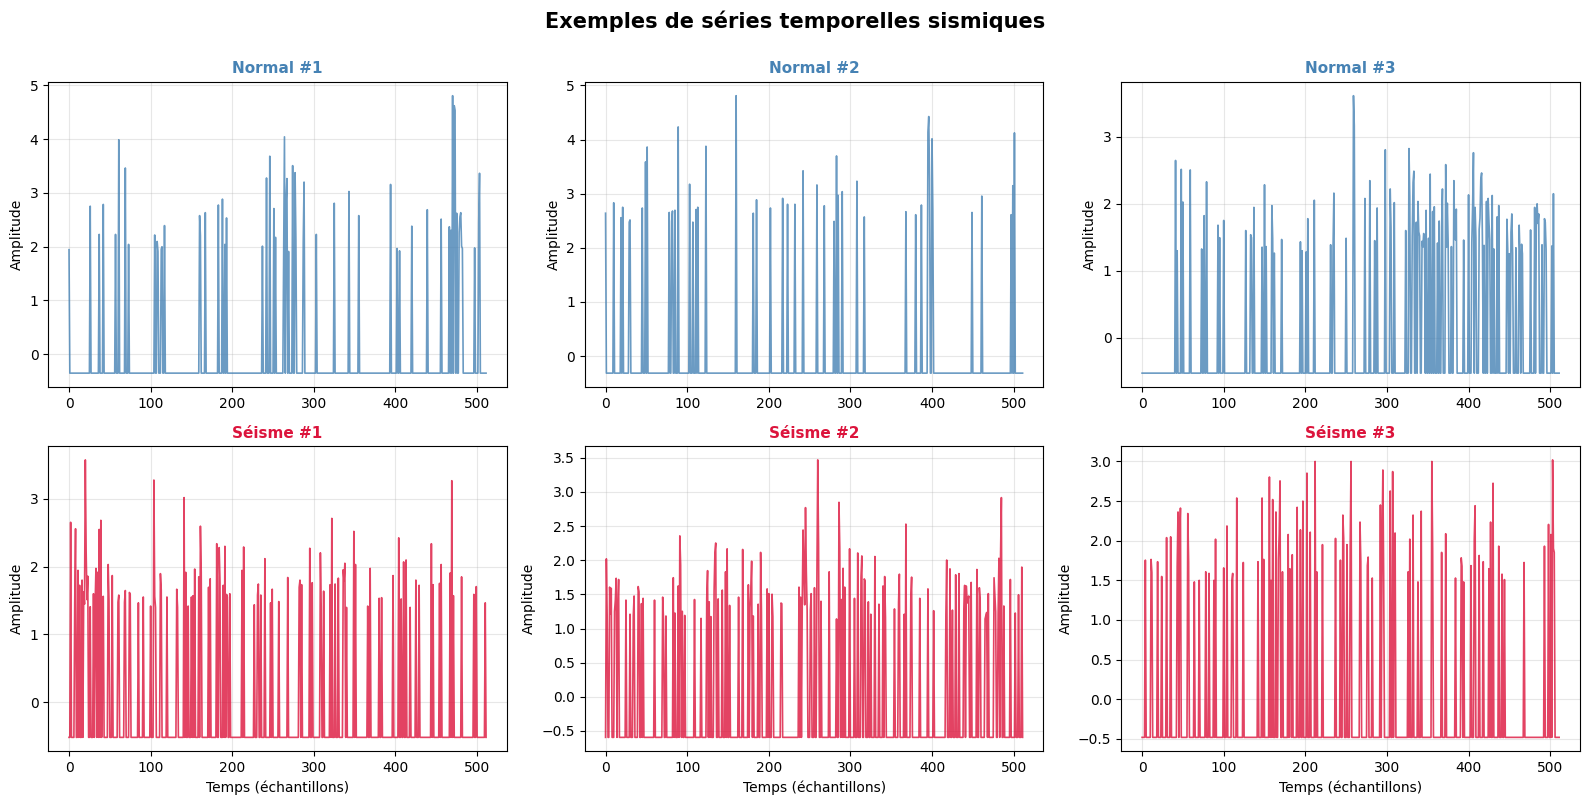


Statistiques des amplitudes moyennes par signal :
  Signaux normaux   : moyenne = -0.000, std = 0.999
  Signaux séismes   : moyenne = 0.000, std = 0.999

Variance moyenne par signal :
  Signaux normaux   : 0.998
  Signaux séismes   : 0.998



ARCHITECTURE AMÉLIORÉE ANTI-OVERFITTING

AMÉLIORATIONS APPLIQUÉES:
1. LSTM au lieu de SimpleRNN (meilleure mémoire à long terme)
2. Dropout augmenté à 0.4 (au lieu de 0.2)
3. Régularisation L2 sur kernel et recurrent weights
4. Batch Normalization pour stabiliser l'entraînement
5. Nombre de neurones réduit (64 au lieu de 128)
6. Learning rate réduit pour convergence plus stable



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,233 (278.25 KB)

 Trainable params: 70,977 (277.25 KB)

 Non-trainable params: 256 (1.00 KB)


ENTRAÎNEMENT DU MODÈLE AMÉLIORÉ

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6001 - loss: 0.7611 - val_accuracy: 0.8462 - val_loss: 0.7020 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 908ms/step - accuracy: 0.5895 - loss: 0.6631 - val_accuracy: 0.8615 - val_loss: 0.6908 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6410 - loss: 0.7847 - val_accuracy: 0.8462 - val_loss: 0.6909 - learning_rate: 0.0010
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5928 - loss: 0.7360 - val_accuracy: 0.8615 - val_loss: 0.7011 - learning_rate: 0.0010
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 877ms/step - accuracy: 0.6243 - loss: 0.7263 - val_accuracy: 0.7538 - val_loss: 0.7045 - learning_rate: 0.0010
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 934ms/step - accuracy: 0.5943 - loss: 0.8305 - val_accuracy: 0.5846 - val_loss: 0.7076 - learning_rate: 0.0010
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 995ms/step - accuracy: 0.5647 - lo

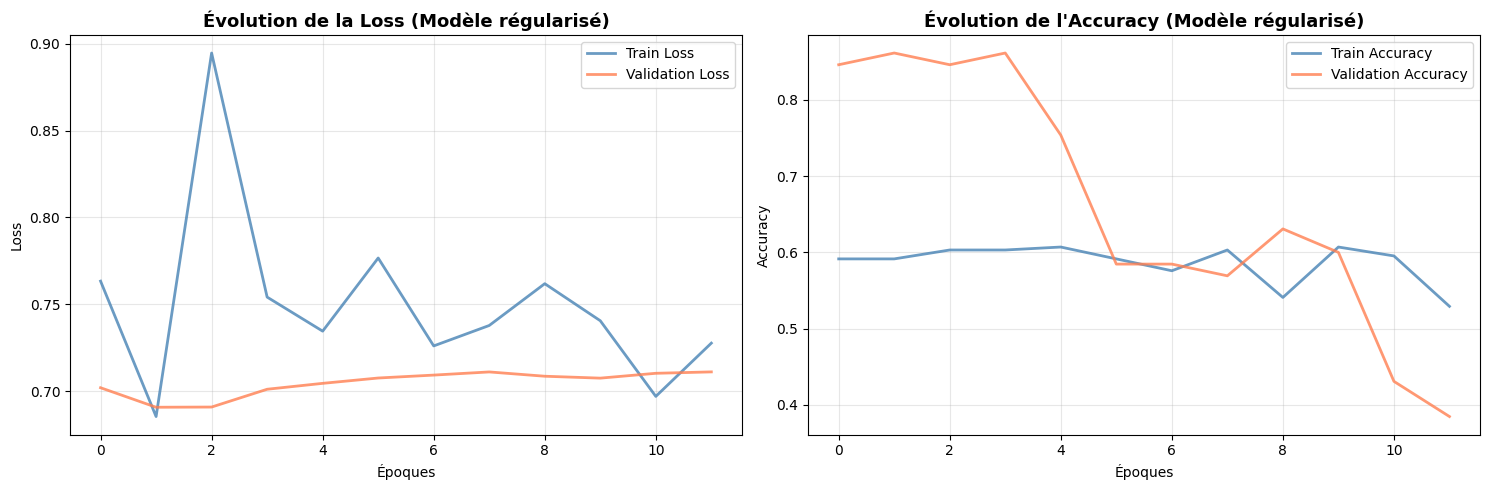


RÉSULTATS FINAUX

Accuracy Test : 0.7698

Rapport de classification :
              precision    recall  f1-score   support

      Normal       0.80      0.92      0.86       104
      Séisme       0.58      0.31      0.41        35

    accuracy                           0.77       139
   macro avg       0.69      0.62      0.63       139
weighted avg       0.74      0.77      0.74       139



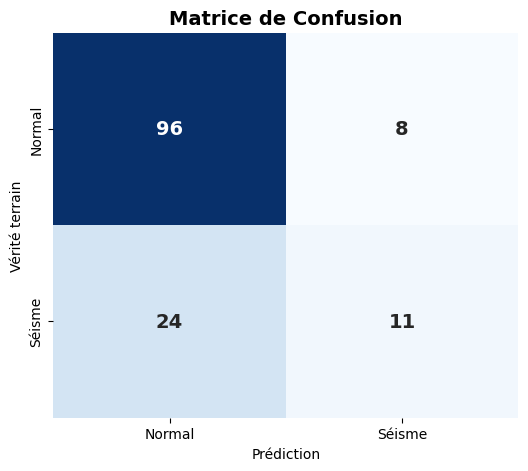

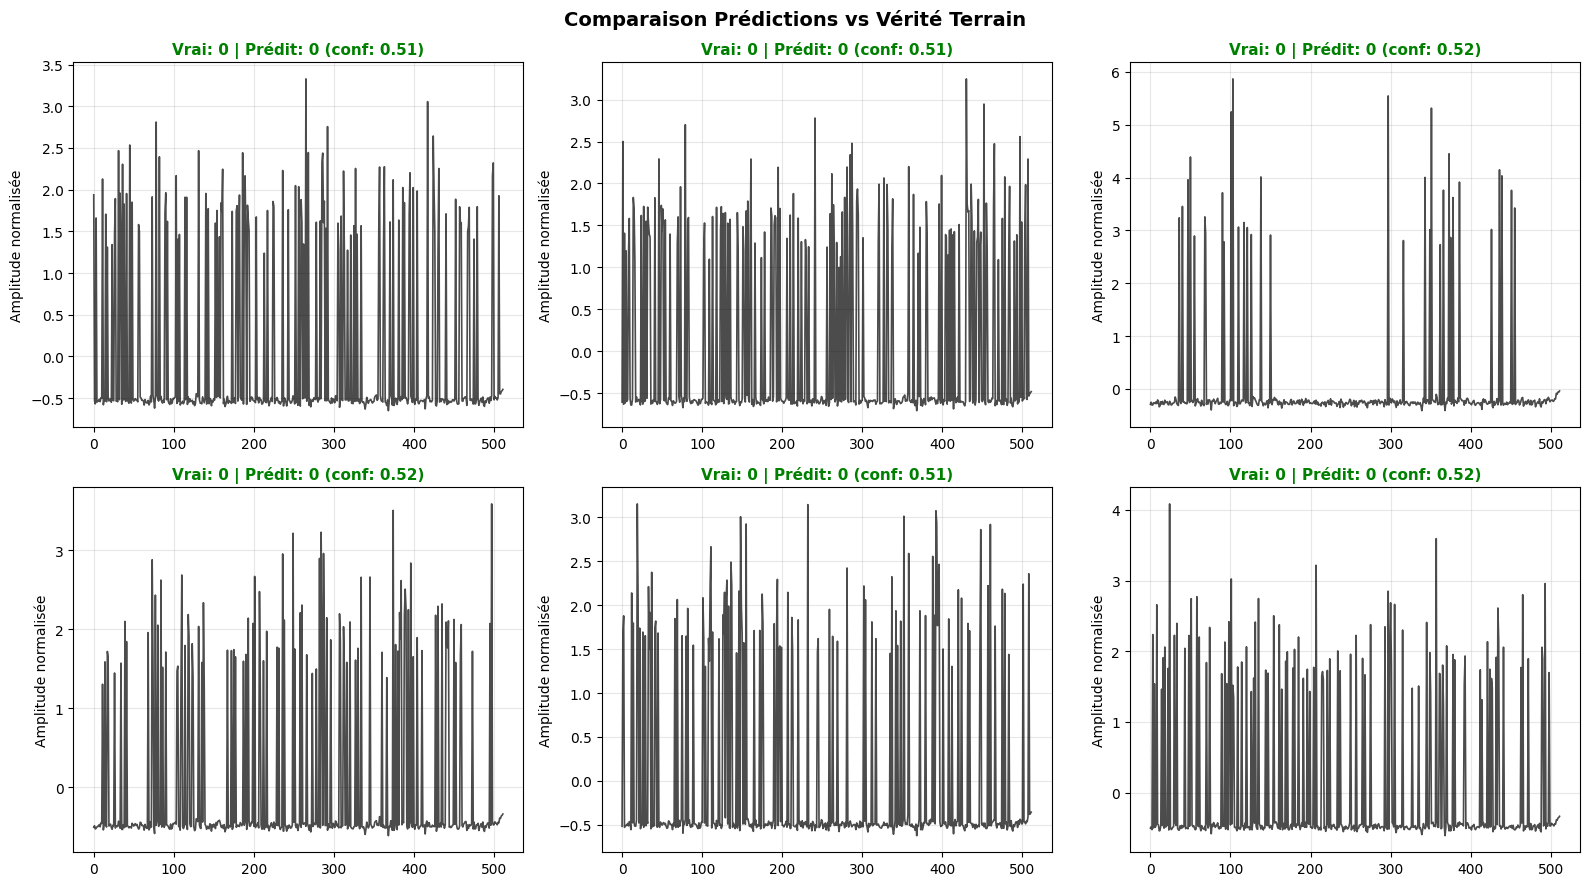


ANALYSE OVERFITTING

Loss finale - Train: 0.7277 | Validation: 0.7111
Écart (gap): 0.0166
✓ Excellent: Pas d'overfitting significatif


In [11]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.utils import class_weight
from scipy.ndimage import uniform_filter1d


TRAIN_URL = "https://maxime-devanne.com/datasets/Earthquakes/Earthquakes_TRAIN.tsv"
TEST_URL  = "https://maxime-devanne.com/datasets/Earthquakes/Earthquakes_TEST.tsv"

print("Chargement...")
train_df = pd.read_csv(TRAIN_URL, sep="\t", header=None)
test_df  = pd.read_csv(TEST_URL,  sep="\t", header=None)

X_train_raw = train_df.iloc[:, 1:].values
y_train_raw = train_df.iloc[:, 0].values
X_test_raw  = test_df.iloc[:, 1:].values
y_test_raw  = test_df.iloc[:, 0].values

print("\n" + "="*60)
print("EXPLORATION DES DONNÉES")
print("="*60)

print(f"\nNombre d'échantillons d'entraînement : {len(X_train_raw)}")
print(f"Nombre d'échantillons de test : {len(X_test_raw)}")
print(f"Longueur de chaque série temporelle : {X_train_raw.shape[1]} points")
print(f"Classes présentes : {np.unique(y_train_raw)}")

y_train_binary = (y_train_raw != np.min(y_train_raw)).astype(np.int32)
y_test_binary = (y_test_raw != np.min(y_train_raw)).astype(np.int32)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
unique, counts = np.unique(y_train_binary, return_counts=True)
axes[0].bar(['Normal', 'Séisme'], counts, color=['skyblue', 'salmon'], alpha=0.7, edgecolor='black')
axes[0].set_title('Distribution des classes (Train)', fontsize=13, weight='bold')
axes[0].set_ylabel('Nombre d\'échantillons')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11, weight='bold')

unique_test, counts_test = np.unique(y_test_binary, return_counts=True)
axes[1].bar(['Normal', 'Séisme'], counts_test, color=['skyblue', 'salmon'], alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution des classes (Test)', fontsize=13, weight='bold')
axes[1].set_ylabel('Nombre d\'échantillons')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(counts_test):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=11, weight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Exemples de séries temporelles sismiques', fontsize=15, weight='bold', y=1.00)

normal_indices = np.where(y_train_binary == 0)[0][:3]
for i, idx in enumerate(normal_indices):
    axes[0, i].plot(X_train_raw[idx], color='steelblue', linewidth=1.2, alpha=0.8)
    axes[0, i].set_title(f'Normal #{i+1}', fontsize=11, color='steelblue', weight='bold')
    axes[0, i].grid(alpha=0.3)
    axes[0, i].set_ylabel('Amplitude')

earthquake_indices = np.where(y_train_binary == 1)[0][:3]
for i, idx in enumerate(earthquake_indices):
    axes[1, i].plot(X_train_raw[idx], color='crimson', linewidth=1.2, alpha=0.8)
    axes[1, i].set_title(f'Séisme #{i+1}', fontsize=11, color='crimson', weight='bold')
    axes[1, i].grid(alpha=0.3)
    axes[1, i].set_ylabel('Amplitude')
    axes[1, i].set_xlabel('Temps (échantillons)')

plt.tight_layout()
plt.show()

print("\nStatistiques des amplitudes moyennes par signal :")
print(f"  Signaux normaux   : moyenne = {X_train_raw[y_train_binary==0].mean():.3f}, std = {X_train_raw[y_train_binary==0].std():.3f}")
print(f"  Signaux séismes   : moyenne = {X_train_raw[y_train_binary==1].mean():.3f}, std = {X_train_raw[y_train_binary==1].std():.3f}")

variance_normal = np.var(X_train_raw[y_train_binary==0], axis=1).mean()
variance_earthquake = np.var(X_train_raw[y_train_binary==1], axis=1).mean()
print(f"\nVariance moyenne par signal :")
print(f"  Signaux normaux   : {variance_normal:.3f}")
print(f"  Signaux séismes   : {variance_earthquake:.3f}")
print("\n" + "="*60 + "\n")

def smooth_data(X, size=1):
    return uniform_filter1d(X, size=size, axis=1)

X_train_smooth = smooth_data(X_train_raw, size=1)
X_test_smooth  = smooth_data(X_test_raw, size=1)

y_train = y_train_binary
y_test  = y_test_binary

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_smooth)
X_test  = scaler.transform(X_test_smooth)

X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train)

weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weights_dict = dict(enumerate(weights))


model = keras.Sequential([
    keras.Input(shape=(X_tr.shape[1], 1)),

    layers.LSTM(
        128,
        dropout=0.5,
        recurrent_dropout=0.5,
        kernel_regularizer=regularizers.l2(1e-4),
        recurrent_regularizer=regularizers.l2(1e-4),
        return_sequences=False
    ),

    layers.BatchNormalization(),

    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2, color='steelblue', alpha=0.8)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='coral', alpha=0.8)
axes[0].set_title("Évolution de la Loss (Modèle régularisé)", fontsize=13, weight='bold')
axes[0].set_xlabel("Époques")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, color='steelblue', alpha=0.8)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='coral', alpha=0.8)
axes[1].set_title("Évolution de l'Accuracy (Modèle régularisé)", fontsize=13, weight='bold')
axes[1].set_xlabel("Époques")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

y_pred_proba = model.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_proba >= 0.5).astype(np.int32)

print(f"\nAccuracy Test : {accuracy_score(y_test, y_pred):.4f}")

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Séisme']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Normal", "Séisme"], yticklabels=["Normal", "Séisme"],
            annot_kws={"size": 14, "weight": "bold"})
plt.title("Matrice de Confusion", fontsize=14, weight='bold')
plt.ylabel('Vérité terrain')
plt.xlabel('Prédiction')
plt.show()

indices = np.random.choice(len(X_test), 6, replace=False)
plt.figure(figsize=(16, 9))
for i, idx in enumerate(indices):
    plt.subplot(2, 3, i+1)
    plt.plot(X_test[idx], color='black', alpha=0.7, linewidth=1.2)
    col = 'green' if y_test[idx] == y_pred[idx] else 'red'
    confidence = y_pred_proba[idx] if y_pred[idx] == 1 else 1 - y_pred_proba[idx]
    plt.title(f"Vrai: {y_test[idx]} | Prédit: {y_pred[idx]} (conf: {confidence:.2f})",
              color=col, fontsize=11, weight='bold')
    plt.grid(alpha=0.3)
    plt.ylabel('Amplitude normalisée')
plt.suptitle("Comparaison Prédictions vs Vérité Terrain", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


